In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder

## PCA implementation from scratch

In [27]:
class PCA:

    def __init__(self, k=None):
        self.k = k
        self.mean = None
        self.Q = None
        self.eigenvalues = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)

        shifted = X - self.mean

        cov = np.dot(shifted.T, shifted) / (len(X) - 1)

        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        order = np.argsort(np.abs(eigenvalues))[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]

        self.eigenvalues = eigenvalues

        if self.k is not None:
            eigenvectors = eigenvectors[:, :self.k]

        self.Q = eigenvectors.T

    def transform(self, X):
        shifted = X - self.mean
        return np.dot(self.Q, shifted.T).T

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X_reduced):
        return np.dot(self.Q.T, X_reduced.T).T + self.mean

    def get_explained_variance_ratio(self):
        total = np.sum(np.abs(self.eigenvalues))
        return np.abs(self.eigenvalues) / total
    



## Naive Bayes Models from Scratch 

In [28]:
class GaussianNB:
    def fit(self, X, y):
        # Find all the unique classes in the target variable
        self.classes = np.unique(y)
        
        self.means = {}
        self.vars = {}
        self.priors = {}
        
        # Calculate mean, variance, and prior probability for each class separately
        for c in self.classes:
            # Filter the training data to only include rows for this specific class
            X_c = X[y == c]
            
            self.means[c] = np.mean(X_c, axis=0)
            self.vars[c] = np.var(X_c, axis=0) + 1e-9 
            
            # Calculate the prior probability of this class (how common it is in the training data)
            self.priors[c] = len(X_c) / len(X)

    def predict(self, X):
        y_pred = []
        
        for x in X:
            posteriors = []
            
            for c in self.classes:
                prior = np.log(self.priors[c])
                
                mean = self.means[c]
                var = self.vars[c]
                
                numerator = np.exp(-((x - mean) ** 2) / (2 * var))
                denominator = np.sqrt(2 * np.pi * var)
                
                likelihood = np.sum(np.log(numerator / denominator))
                
                total_prob = prior + likelihood
                posteriors.append(total_prob)
                
            best_class_idx = np.argmax(posteriors)
            y_pred.append(self.classes[best_class_idx])
            
        return np.array(y_pred)


class CategoricalNB:
    def __init__(self, alpha=1.0):
        # alpha is for Laplace smoothing to handle categories we haven't seen before
        self.alpha = alpha 

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.priors = {}
        self.probs = {} 
        
        n_samples, n_features = X.shape
        
        for c in self.classes:
            X_c = X[y == c]
            
            self.priors[c] = len(X_c) / n_samples
            self.probs[c] = {}
            
            for f in range(n_features):
                self.probs[c][f] = {}
                
                feature_values = np.unique(X[:, f])
                num_unique_values = len(feature_values)
                
                for val in feature_values:
                    val_count = np.sum(X_c[:, f] == val)
                    
                    prob = (val_count + self.alpha) / (len(X_c) + self.alpha * num_unique_values)
                    self.probs[c][f][val] = prob

    def predict(self, X):
        y_pred = []
        
        for x in X:
            posteriors = []
            
            for c in self.classes:
                posterior = np.log(self.priors[c])
                
                for f in range(len(x)):
                    val = x[f]
                    if val in self.probs[c][f]:
                        posterior += np.log(self.probs[c][f][val])
                    else:
                        posterior += np.log(1e-6) 
                        
                posteriors.append(posterior)
                
            best_class_idx = np.argmax(posteriors)
            y_pred.append(self.classes[best_class_idx])
            
        return np.array(y_pred)

### Function to help evaluate every experiment

In [29]:
def evaluate_model(y_true, y_pred, experiment_name):
    print(f"--- {experiment_name} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))
    print("=" * 50)

## Categorical Data loading and preprocessing

In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/mushroom-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\mohamed\.cache\kagglehub\datasets\uciml\mushroom-classification\versions\1


In [31]:
mushroom = pd.read_csv(path + "/mushrooms.csv")
mushroom.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [32]:
mushroom.isnull().sum()
# Check for missing values or nulls in the dataset

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [33]:
mushroom['stalk-root'].value_counts()

#there are no nulls however there are some missing data represented by '?' 
# which will be replaced with the most frequent value in that column

stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64

In [34]:
x_cat = mushroom.drop("class", axis=1)
y_cat = mushroom["class"]

# Replace '?' with NaN and fill with mode
x_cat = x_cat.replace('?', pd.NA)
for col in x_cat.columns:
    x_cat[col] = x_cat[col].fillna(x_cat[col].mode()[0])


# Encode categorical features using OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
x_cat_encoded = ordinal_encoder.fit_transform(x_cat)

# Encode target variable using LabelEncoder
label_encoder = LabelEncoder()
y_cat_encoded = label_encoder.fit_transform(y_cat)

#splitting the data into training and testing sets
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(x_cat_encoded, y_cat_encoded, test_size=0.2, random_state=42)

print("Training set shape:", X_train_cat.shape)

Training set shape: (6499, 22)


## Experimental Pipeline (categorical)

In [35]:
# Experiment 0: Baseline (All Features + Naive Bayes)
nb_cat = CategoricalNB()
nb_cat.fit(X_train_cat, y_train_cat)
y_pred_cat = nb_cat.predict(X_test_cat)
evaluate_model(y_test_cat, y_pred_cat, "Mushroom Baseline")

# Range of k values to test for both feature selection and PCA
k_values_cat = range(2, 23)

# Experiment A: Feature Selection + Naive Bayes (Best K Search)
best_k_fs = 0
best_acc_fs = 0
best_y_pred_fs = None

for k in k_values_cat:
    selector_cat = SelectKBest(chi2, k=k)
    X_train_cat_selected = selector_cat.fit_transform(X_train_cat, y_train_cat)
    X_test_cat_selected = selector_cat.transform(X_test_cat)

    nb_cat_selected = CategoricalNB()
    nb_cat_selected.fit(X_train_cat_selected, y_train_cat)
    y_pred = nb_cat_selected.predict(X_test_cat_selected)
    
    acc = accuracy_score(y_test_cat, y_pred)
    if acc > best_acc_fs:
        best_acc_fs = acc
        best_k_fs = k
        best_y_pred_fs = y_pred

evaluate_model(y_test_cat, best_y_pred_fs, f"Mushroom Feature Selection (Best k={best_k_fs})")

# Experiment B: PCA + Naive Bayes (Best K Search)
best_k_pca = 0
best_acc_pca = 0
best_y_pred_pca = None

for k in k_values_cat:
    pca_cat = PCA(k=k)
    X_train_cat_pca = pca_cat.fit_transform(X_train_cat)
    X_test_cat_pca = pca_cat.transform(X_test_cat)
    
    # We still use GaussianNB here because PCA converts categories into continuous numbers
    nb_cat_pca = GaussianNB()
    nb_cat_pca.fit(X_train_cat_pca, y_train_cat)
    y_pred = nb_cat_pca.predict(X_test_cat_pca)
    
    acc = accuracy_score(y_test_cat, y_pred)
    if acc > best_acc_pca:
        best_acc_pca = acc
        best_k_pca = k
        best_y_pred_pca = y_pred

evaluate_model(y_test_cat, best_y_pred_pca, f"Mushroom PCA (Best k={best_k_pca})")

--- Mushroom Baseline ---
Accuracy: 0.9508
Confusion Matrix:
 [[834   9]
 [ 71 711]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95       843
           1       0.99      0.91      0.95       782

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625

--- Mushroom Feature Selection (Best k=18) ---
Accuracy: 0.9520
Confusion Matrix:
 [[834   9]
 [ 69 713]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96       843
           1       0.99      0.91      0.95       782

    accuracy                           0.95      1625
   macro avg       0.96      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625

--- Mushroom PCA (Best k=17) ---
Accuracy: 0.9065
Confusion Matrix:
 [[816  27]
 [125 657]]
Classification 

## Numerical Data loading and preprocessing

In [36]:
cancer=load_breast_cancer()
x_num = cancer.data
y_num = cancer.target

scaler= StandardScaler()
x_num_scaled = scaler.fit_transform(x_num)

X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(x_num_scaled, y_num, test_size=0.2, random_state=42)

print("Training set shape:", X_train_num.shape)

Training set shape: (455, 30)


## Experimental Pipeline (numerical)

In [37]:
# Experiment 0: Baseline (All Features + Naive Bayes)
nb_num = GaussianNB()
nb_num.fit(X_train_num, y_train_num)
y_pred_num = nb_num.predict(X_test_num)
evaluate_model(y_test_num, y_pred_num, "Breast Cancer Baseline")

# Range of k values to test for both feature selection and PCA
k_values_num = range(2, 31)

# Experiment A: Feature Selection + Naive Bayes (Best K Search)
best_k_fs_num = 0
best_acc_fs_num = 0
best_y_pred_fs_num = None

for k in k_values_num:
    selector_num = SelectKBest(f_classif, k=k)
    X_train_num_selected = selector_num.fit_transform(X_train_num, y_train_num)
    X_test_num_selected = selector_num.transform(X_test_num)

    nb_num_selected = GaussianNB()
    nb_num_selected.fit(X_train_num_selected, y_train_num)
    y_pred = nb_num_selected.predict(X_test_num_selected)
    
    acc = accuracy_score(y_test_num, y_pred)
    if acc > best_acc_fs_num:
        best_acc_fs_num = acc
        best_k_fs_num = k
        best_y_pred_fs_num = y_pred

evaluate_model(y_test_num, best_y_pred_fs_num, f"Breast Cancer Feature Selection (Best k={best_k_fs_num})")

# Experiment B: PCA + Naive Bayes (Best K Search)
best_k_pca_num = 0
best_acc_pca_num = 0
best_y_pred_pca_num = None

for k in k_values_num:
    pca_num = PCA(k=k)
    X_train_num_pca = pca_num.fit_transform(X_train_num)
    X_test_num_pca = pca_num.transform(X_test_num)

    nb_num_pca = GaussianNB()
    nb_num_pca.fit(X_train_num_pca, y_train_num)
    y_pred = nb_num_pca.predict(X_test_num_pca)
    
    acc = accuracy_score(y_test_num, y_pred)
    if acc > best_acc_pca_num:
        best_acc_pca_num = acc
        best_k_pca_num = k
        best_y_pred_pca_num = y_pred

evaluate_model(y_test_num, best_y_pred_pca_num, f"Breast Cancer PCA (Best k={best_k_pca_num})")

--- Breast Cancer Baseline ---
Accuracy: 0.9649
Confusion Matrix:
 [[40  3]
 [ 1 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

--- Breast Cancer Feature Selection (Best k=4) ---
Accuracy: 0.9737
Confusion Matrix:
 [[42  1]
 [ 2 69]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

--- Breast Cancer PCA (Best k=3) ---
Accuracy: 0.9474
Confusion Matrix:
 [[38  5]
 [ 1 70]]
Classification

## Visualizations

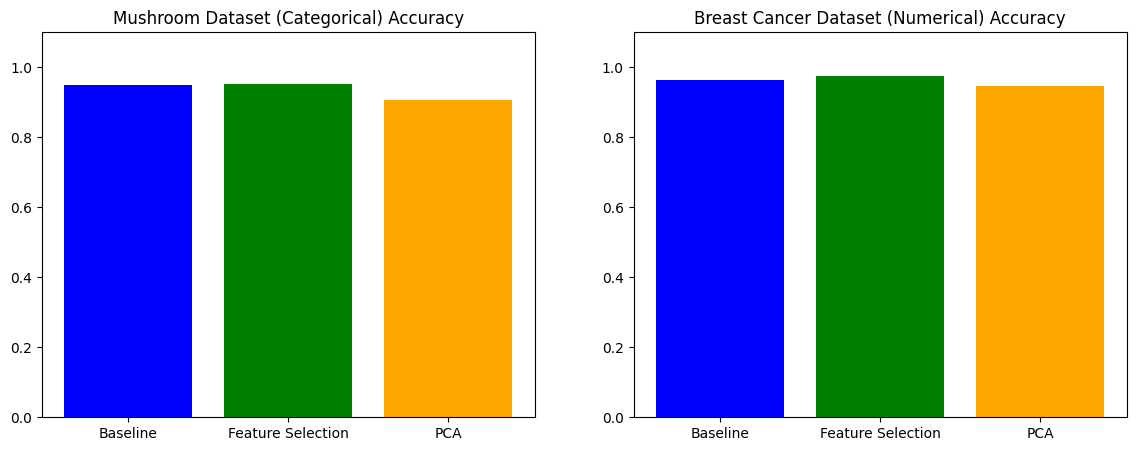

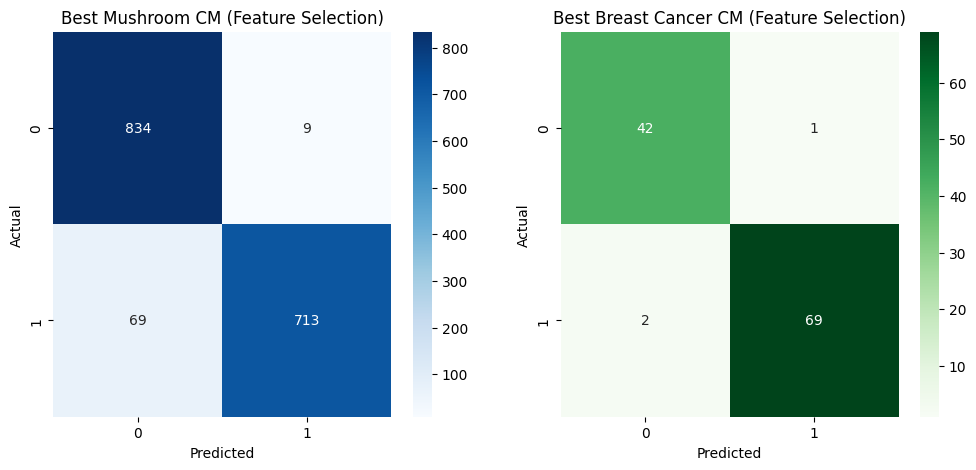

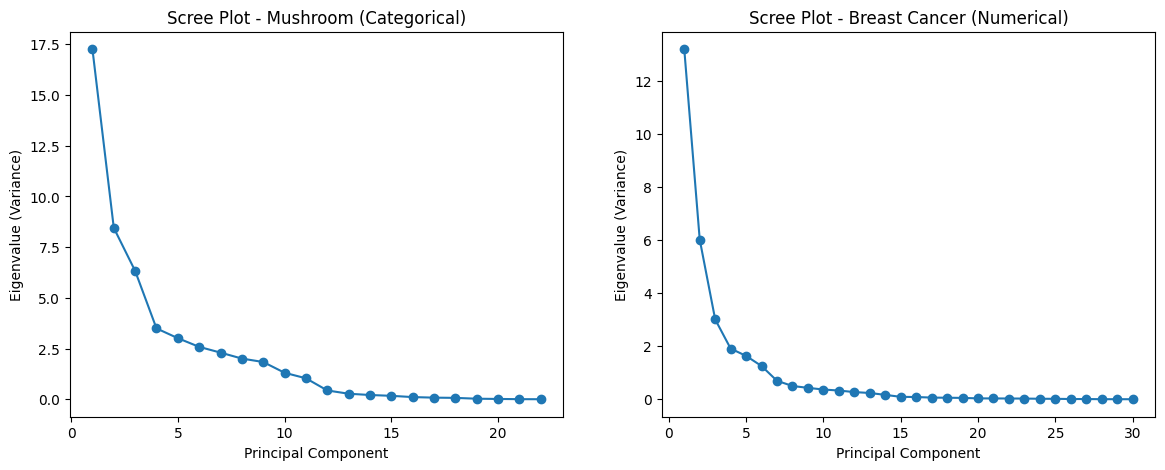

In [39]:

# 1. Accuracy Comparison Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Categorical Accuracies
cat_acc = [accuracy_score(y_test_cat, y_pred_cat), 
           accuracy_score(y_test_cat, best_y_pred_fs), 
           accuracy_score(y_test_cat, best_y_pred_pca)]
# Numerical Accuracies
num_acc = [accuracy_score(y_test_num, y_pred_num), 
           accuracy_score(y_test_num, best_y_pred_fs_num), 
           accuracy_score(y_test_num, best_y_pred_pca_num)]
labels = ['Baseline', 'Feature Selection', 'PCA']

axes[0].bar(labels, cat_acc, color=['blue', 'green', 'orange'])
axes[0].set_title('Mushroom Dataset (Categorical) Accuracy')
axes[0].set_ylim(0, 1.1)

axes[1].bar(labels, num_acc, color=['blue', 'green', 'orange'])
axes[1].set_title('Breast Cancer Dataset (Numerical) Accuracy')
axes[1].set_ylim(0, 1.1)
plt.show()

# 2. Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test_cat, best_y_pred_fs), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Best Mushroom CM (Feature Selection)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test_num, best_y_pred_fs_num), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Best Breast Cancer CM (Feature Selection)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.show()

# 3. Scree Plots for PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# We need to run PCA on the full training sets to get all eigenvalues for the scree plot
pca_full_cat = PCA()
pca_full_cat.fit(X_train_cat)
pca_full_num = PCA()
pca_full_num.fit(X_train_num)

# Mushroom Scree Plot
axes[0].plot(range(1, len(pca_full_cat.eigenvalues) + 1), pca_full_cat.eigenvalues, marker='o')
axes[0].set_title('Scree Plot - Mushroom (Categorical)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Eigenvalue (Variance)')

# Breast Cancer Scree Plot
axes[1].plot(range(1, len(pca_full_num.eigenvalues) + 1), pca_full_num.eigenvalues, marker='o')
axes[1].set_title('Scree Plot - Breast Cancer (Numerical)')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Eigenvalue (Variance)')
plt.show()